Assignment 1

In [25]:
library(fpp3)

get_my_data <- function(student_id) {
  set.seed(student_id)
  all_data <- readr::read_rds("https://bit.ly/monashretaildata")
  while(TRUE) {
    retail <- filter(all_data, `Series ID` == sample(`Series ID`, 1))
    if(!any(is.na(fill_gaps(retail)$Turnover))) return(retail)
  }
}

retail <- get_my_data(2211769)

1. Plot your time series using the `autoplot()` command. What do you learn from the plot?

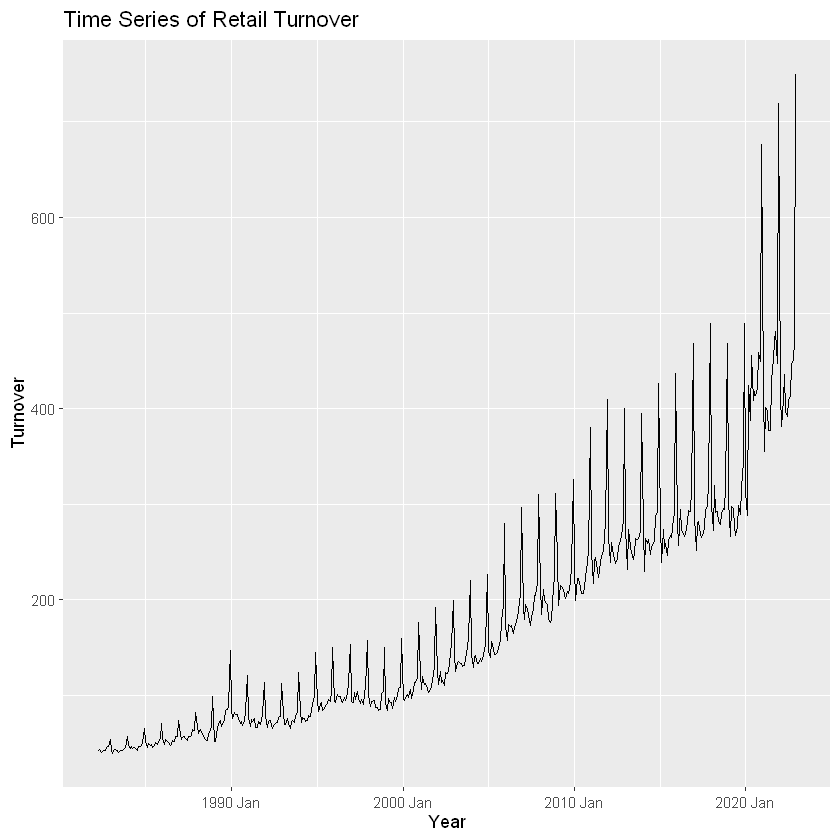

In [26]:
autoplot(retail, Turnover) +
  ggtitle("Time Series of Retail Turnover") +
  xlab("Year") + ylab("Turnover")

Grafikas atskleidžia ryškią didėjimo tendenciją, atspindinčią ilgalaikį ekonominį augimą, bei griežtą sezoniškumą su reguliariais kasmetiniais pikai. Duomenys pasižymi akivaizdžiu heteroskedastiškumu – augant bendrai apyvartai, sezoninių svyravimų amplitudė didėja, o tai indikuoja multiplikatyvų eilutės pobūdį ir būtinybę ateityje taikyti dispersiją stabilizuojančias transformacijas (pvz., logaritmavimą). Taip pat eilutės pabaigoje (2020–2021 m.) stebimas ryškus struktūrinis lūžis – staigus kritimas ir nestabilus atsigavimas, tiesiogiai sietinas su COVID-19 pandemijos suvaržymais bei po jų sekusiais vartotojų elgsenos pokyčiais.


2. Plot your time series using the `gg_season()` command. What do you learn from the plot?


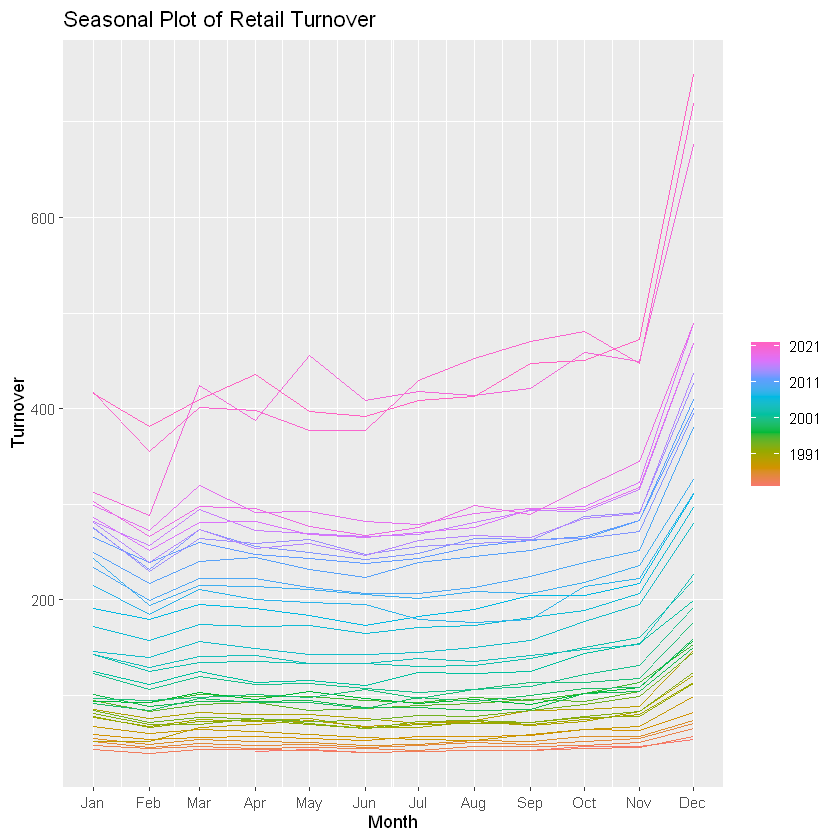

In [27]:
gg_season(retail, Turnover) +
  ggtitle("Seasonal Plot of Retail Turnover") +
  xlab("Month") + ylab("Turnover")


Grafikas vizualiai patvirtina griežtą duomenų sezoniškumą, kuriame dominuoja kasmetinis apyvartos pikas gruodžio mėnesį, siejamas su šventiniu laikotarpiu, bei nuoseklus atoslūgis metų pradžioje. Grafike stebimas aiškus linijų „sluoksniavimas“ (naujesni metai viršuje) ir didėjanti atstumų tarp piko ir dugno amplitudė vėlesniais metais dar kartą pagrindžia ilgalaikę augimo tendenciją bei multiplikatyvų duomenų pobūdį. Taip pat išskirtinė 2020–2021 m. kreivių elgsena (pvz., netipiškas nuosmukis pavasarį ir padidėjęs nestabilumas) indikuoja struktūrinį lūžį, kurį lėmė COVID-19 pandemijos suvaržymai, laikinai iškreipę įprastą sezoninį ciklą.

3. Plot your time series using the `gg_subseries()` command. What do you learn from the plot?

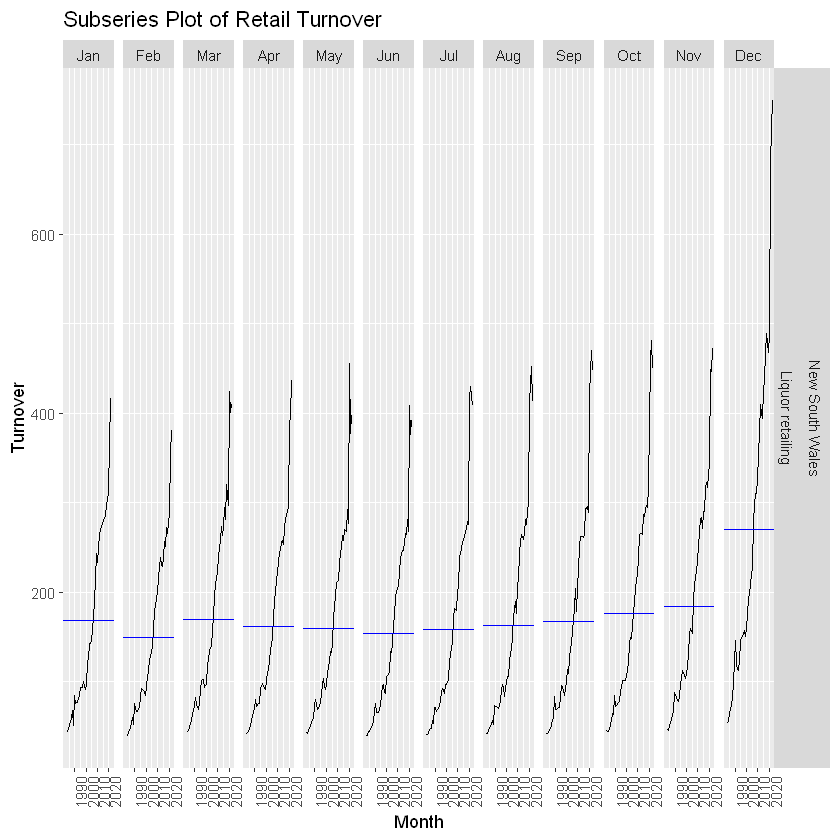

In [28]:
gg_subseries(retail, Turnover) +
  ggtitle("Subseries Plot of Retail Turnover") +
  xlab("Month") + ylab("Turnover")

Grafikas atskleidžia, kad mažmeninės prekybos apyvarta sistemingai auga visais metų mėnesiais, tačiau augimo tempai skiriasi. Ryškiausiai išsiskiria gruodžio mėnuo, kurio apyvartos vidurkis ir augimo statumas žymiai viršija kitų mėnesių rodiklius, patvirtinant stiprėjantį šventinio laikotarpio efektą. Grafike taip pat aiškiai identifikuojama COVID-19 pandemijos įtaka: specifiniuose pavasario mėnesių (ypač balandžio ir gegužės) grafikuose eilutės pabaigoje stebimi staigūs kryčiai, atspindintys tuo metu įvestus griežtus karantino ribojimus, tuo tarpu kitais mėnesiais šis efektas nėra toks ryškus arba pasireiškia vėlesniu atsigavimu.

4. Find an appropriate Box-Cox transformation for your data and explain why you have chosen the particular transformation parameter $\lambda$.

State,Industry,lambda_guerrero
<chr>,<chr>,<dbl>
New South Wales,Liquor retailing,-0.06255411


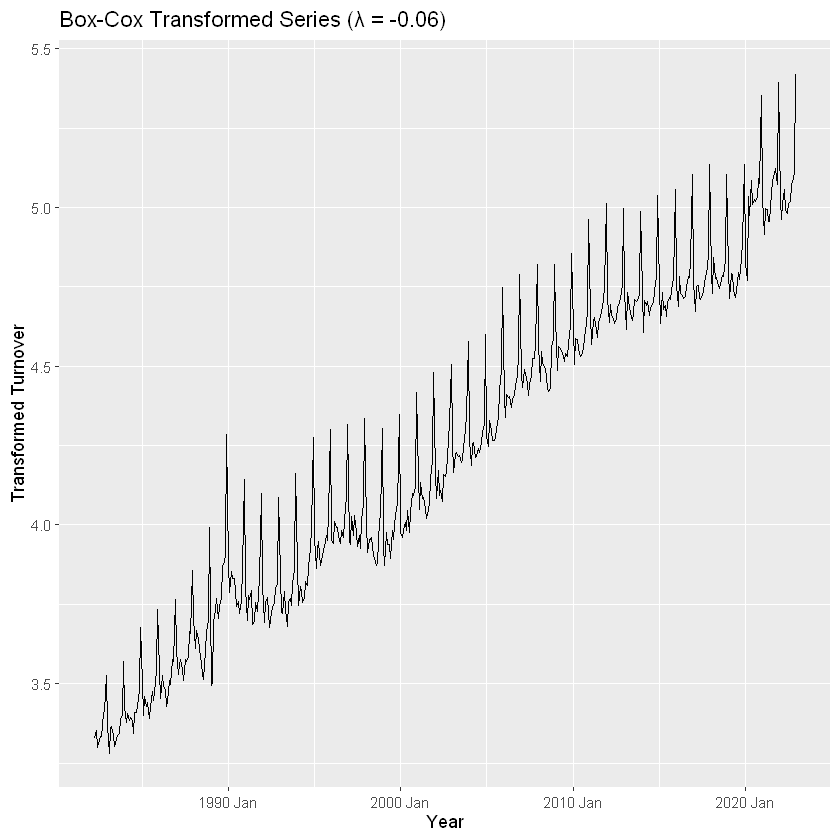

In [29]:
lambda <- retail %>% 
  features(Turnover, features = guerrero)

lambda

retail_transformed <- retail %>% 
  mutate(Turnover_transformed = box_cox(Turnover, lambda$lambda_guerrero))

autoplot(retail_transformed, Turnover_transformed) +
  ggtitle(paste0("Box-Cox Transformed Series (λ = ", 
                 round(lambda$lambda_guerrero, 2), ")")) +
  xlab("Year") + ylab("Transformed Turnover")

Siekiant stabilizuoti laiko eilutės dispersiją (pašalinti heteroskedastiškumą), pritaikyta Box-Cox transformacija. Optimalus parametras parinktas naudojant Guerrero metodą, kuris minimizuoja sezoniškumo variaciją, ir gauta reikšmė yra $\lambda \approx -0.06$. Ši reikšmė yra artima nuliui, kas atitinka natūrinio logaritmo transformaciją ir patvirtina multiplikatyvų duomenų pobūdį – būdingą bruožą mažmeninės prekybos apyvartai, kur augimas ir svyravimai priklauso nuo procentinių pokyčių (infliacijos, perkamosios galios). Transformuotos eilutės grafikas rodo, kad sezoninių svyravimų amplitudė tapo tolygi per visą laikotarpį, todėl duomenys tapo tinkami adityviems prognozavimo modeliams.

5. Produce a plot of an STL decomposition of the transformed data. What do you learn from the plot?

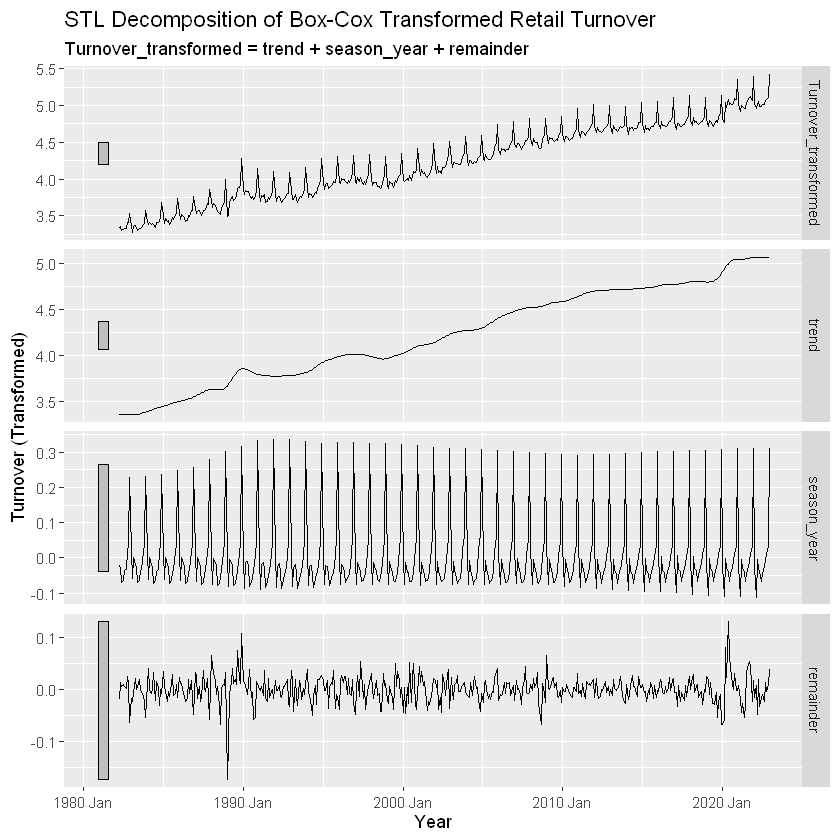

In [30]:
stl_fit <- retail_transformed %>%
  model(STL(Turnover_transformed))

components(stl_fit) %>%
  autoplot() +
  ggtitle("STL Decomposition of Box-Cox Transformed Retail Turnover") +
  xlab("Year") + ylab("Turnover (Transformed)")

STL dekompozicija išskaido Box-Cox transformuotą eilutę į tendencijos, sezoniškumo ir liekanų komponentus. Tendencijos kreivė rodo ilgalaikį augimą, tačiau išryškina ir ekonominius ciklus: aiškiai matomas stagnacijos periodas 1990-ųjų pradžioje (sietinas su ekonomine recesija) bei nestabilumas 2020–2021 m. Sezoninis komponentas pasižymi pastovia amplitude, kas patvirtina sėkmingą dispersijos stabilizavimą transformacijos metu. Analizuojant liekanas (remainder), stebimas mažas triukšmo lygis (ką indikuoja santykinai didelis pilkas mastelio stulpelis kairėje), tačiau pabaigoje fiksuojami dideli nuokrypiai. Šie „spygliai“ rodo, kad COVID-19 pandemijos sukelti struktūriniai lūžiai buvo netipiški ir negali būti paaiškinti standartiniais sezoniškumo ar tendencijos modeliais.

In [31]:
print(R, ...)

ERROR: Error: '...' used in an incorrect context
